# <center>Ciencia de datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Redes Neuronales</center>



# Grid Search con Validación Cruzada para Redes Neuronales en Keras

Este notebook demuestra cómo realizar una búsqueda de hiperparámetros (Grid Search) con validación cruzada para modelos de redes neuronales utilizando Keras.


In [1]:
"""
Keras Grid Search CV Example - Manual Implementation
This notebook demonstrates how to perform grid search with cross-validation using Keras models
"""

# Install required packages
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.19.0


Generemos datos sintéticos para demostrar la funcionalidad. En un proyecto real, aquí se cargarían los propios datos reales. La preparación adecuada de los datos es fundamental para el éxito del modelo.

In [2]:
# 1. Generate some example data (you'll replace this with your actual data)
# Let's create a simple classification dataset using make_classification
from sklearn.datasets import make_classification

# Generate synthetic data
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_classes=3,
    random_state=42
)

# Convert target to one-hot encoding for Keras
y_onehot = keras.utils.to_categorical(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Number of classes: {y_train.shape[1]}")



Training data shape: (800, 20)
Training labels shape: (800, 3)
Number of classes: 3


Ahora que tenemos nuestros datos preparados, vamos a definir la arquitectura de nuestra red neuronal. Crearemos una función que pueda generar diferentes modelos según los hiperparámetros que le pasemos.

Esta flexibilidad nos permitirá explorar sistemáticamente diferentes configuraciones para encontrar la que mejor se ajuste a nuestro problema.


In [3]:
# 2. Define the model creation function
def create_model(n_hidden=1, units=32, dropout_rate=0.2, learning_rate=0.001, activation='relu'):
    """Create a Keras neural network with configurable hyperparameters"""

    # Get input and output dimensions
    input_dim = X_train_scaled.shape[1]
    output_dim = y_train.shape[1]

    # Create model
    model = keras.Sequential()

    # Add first hidden layer
    model.add(keras.layers.Dense(units,
                                input_shape=(input_dim,),
                                activation=activation))
    model.add(keras.layers.Dropout(dropout_rate))

    # Add additional hidden layers if requested
    for _ in range(n_hidden - 1):
        model.add(keras.layers.Dense(units, activation=activation))
        model.add(keras.layers.Dropout(dropout_rate))

    # Add output layer
    model.add(keras.layers.Dense(output_dim, activation='softmax'))

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



Con nuestra función de creación de modelos definida, ahora necesitamos especificar qué hiperparámetros queremos explorar. La cuadrícula de parámetros define todas las combinaciones posibles que probaremos.

Cada combinación de estos parámetros representa una configuración diferente de la red neuronal y será evaluada mediante validación cruzada.  Una cuadrícula más amplia explorará más posibilidades, pero requerirá mucho más tiempo de cómputo.


In [4]:
# 3. Define parameter grid
param_grid = {
    'n_hidden': [1, 2],
    'units': [16, 32, 64],
    'dropout_rate': [0.2, 0.5],
    'learning_rate': [0.01, 0.001],
    'activation': ['relu', 'tanh'],
    'batch_size': [16, 32, 64],
    'epochs': [10, 20]
}


Esta es la parte central del notebook. Aquí implementamos manualmente el proceso de búsqueda de hiperparámetros con validación cruzada, evaluando cada combinación de parámetros definida en múltiples particiones de los datos.

Para cada combinación, dividiremos los datos en varios pliegues (folds) y entrenaremos un modelo en cada pliegue, evaluando su rendimiento en los datos de validación. El rendimiento promedio a través de todos los pliegues nos dará una estimación más robusta del rendimiento esperado.


In [5]:
# 4. Manual Grid Search with Cross-Validation Implementation
def grid_search_cv(param_grid, n_splits=3):
    """
    Perform grid search with cross-validation for Keras models

    Args:
        param_grid: Dictionary with parameters names as keys and lists of parameter values
        n_splits: Number of folds for cross-validation

    Returns:
        results_df: DataFrame with all results
        best_params: Dictionary with best parameters
    """
    # Create all combinations of parameters
    from itertools import product
    param_combinations = list(product(*(param_grid[param] for param in param_grid)))

    # Create a list to store all results
    all_results = []

    # Create KFold cross-validator
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Track best parameters and best score
    best_score = -np.inf
    best_params = None

    # Loop through all parameter combinations
    for i, params in enumerate(param_combinations):
        # Create a dictionary with parameter names and values
        param_dict = dict(zip(param_grid.keys(), params))

        print(f"\nEvaluating parameters {i+1}/{len(param_combinations)}:")
        for k, v in param_dict.items():
            print(f"  {k}: {v}")

        # Extract non-model parameters
        batch_size = param_dict['batch_size']
        epochs = param_dict['epochs']

        # Create model parameters dict (exclude training parameters)
        model_params = {k: v for k, v in param_dict.items()
                       if k not in ['batch_size', 'epochs']}

        # Initialize list to store scores for this parameter set
        cv_scores = []

        # Perform cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
            print(f"  Fold {fold+1}/{n_splits}")

            # Split data for this fold
            X_fold_train = X_train_scaled[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train_scaled[val_idx]
            y_fold_val = y_train[val_idx]

            # Create and train model
            model = create_model(**model_params)

            # Create early stopping callback to prevent overfitting
            early_stopping = keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True
            )

            # Train the model
            history = model.fit(
                X_fold_train, y_fold_train,
                epochs=epochs,
                batch_size=batch_size,
                validation_data=(X_fold_val, y_fold_val),
                verbose=0,
                callbacks=[early_stopping]
            )

            # Get best validation accuracy
            best_val_acc = max(history.history['val_accuracy'])
            cv_scores.append(best_val_acc)

            print(f"    Best validation accuracy: {best_val_acc:.4f}")

        # Calculate mean CV score
        mean_cv_score = np.mean(cv_scores)
        std_cv_score = np.std(cv_scores)

        print(f"  Mean CV accuracy: {mean_cv_score:.4f} ± {std_cv_score:.4f}")

        # Store results
        result = {
            **param_dict,
            'mean_cv_accuracy': mean_cv_score,
            'std_cv_accuracy': std_cv_score
        }
        all_results.append(result)

        # Update best parameters if needed
        if mean_cv_score > best_score:
            best_score = mean_cv_score
            best_params = param_dict
            print(f"  New best parameters found!")

    # Convert results to DataFrame
    results_df = pd.DataFrame(all_results)

    return results_df, best_params



En esta sección ejecutamos la búsqueda utilizando una cuadrícula reducida para demostración.

En un escenario real, se podría expandir la cuadrícula para explorar más combinaciones, o iniciar con una búsqueda amplia y luego refinar alrededor de los mejores valores encontrados.


In [6]:
# 5. Run grid search (using a smaller parameter grid for demonstration)
# For a real run, use the full param_grid defined above
demo_param_grid = {
    'n_hidden': [1],
    'units': [32, 64],
    'dropout_rate': [0.2],
    'learning_rate': [0.001],
    'activation': ['relu', 'tanh'],
    'batch_size': [32],
    'epochs': [10]
}

# Uncomment the next two lines to run the full grid search (takes time!)
print("Starting grid search...")
results_df, best_params = grid_search_cv(demo_param_grid, n_splits=3)
# results_df, best_params = grid_search_cv(param_grid, n_splits=3)

# Display results sorted by performance
print("\nAll Results (sorted by mean CV accuracy):")
sorted_results = results_df.sort_values('mean_cv_accuracy', ascending=False)
print(sorted_results)

print("\nBest Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")



Starting grid search...

Evaluating parameters 1/4:
  n_hidden: 1
  units: 32
  dropout_rate: 0.2
  learning_rate: 0.001
  activation: relu
  batch_size: 32
  epochs: 10
  Fold 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Best validation accuracy: 0.5955
  Fold 2/3
    Best validation accuracy: 0.6554
  Fold 3/3
    Best validation accuracy: 0.6203
  Mean CV accuracy: 0.6237 ± 0.0246
  New best parameters found!

Evaluating parameters 2/4:
  n_hidden: 1
  units: 32
  dropout_rate: 0.2
  learning_rate: 0.001
  activation: tanh
  batch_size: 32
  epochs: 10
  Fold 1/3
    Best validation accuracy: 0.6442
  Fold 2/3
    Best validation accuracy: 0.6217
  Fold 3/3
    Best validation accuracy: 0.6541
  Mean CV accuracy: 0.6400 ± 0.0136
  New best parameters found!

Evaluating parameters 3/4:
  n_hidden: 1
  units: 64
  dropout_rate: 0.2
  learning_rate: 0.001
  activation: relu
  batch_size: 32
  epochs: 10
  Fold 1/3
    Best validation accuracy: 0.6629
  Fold 2/3
    Best validation accuracy: 0.6592
  Fold 3/3
    Best validation accuracy: 0.6767
  Mean CV accuracy: 0.6663 ± 0.0075
  New best parameters found!

Evaluating parameters 4/4:
  n_hidden: 1
  units: 64
  dropout_rate: 0.2
  learning_rate: 0

Ahora tenemos los resultados de nuestra búsqueda de hiperparámetros. Podemos ver qué combinación de parámetros produjo el mejor rendimiento promedio en la validación cruzada.

El siguiente paso es entrenar un modelo final utilizando estos parámetros óptimos en todo el conjunto de entrenamiento.


In [7]:
# 6. Train final model with best parameters
print("\nTraining final model with best parameters...")

# Extract non-model parameters
final_batch_size = best_params['batch_size']
final_epochs = best_params['epochs']

# Create model parameters dict (exclude training parameters)
final_model_params = {k: v for k, v in best_params.items()
                     if k not in ['batch_size', 'epochs']}

# Create and train final model
final_model = create_model(**final_model_params)

# Train with early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

# Train final model
history = final_model.fit(
    X_train_scaled, y_train,
    epochs=final_epochs,
    batch_size=final_batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)




Training final model with best parameters...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4500 - loss: 1.0707 - val_accuracy: 0.5562 - val_loss: 0.9668
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5219 - loss: 0.9832 - val_accuracy: 0.6000 - val_loss: 0.9058
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6047 - loss: 0.9151 - val_accuracy: 0.6250 - val_loss: 0.8587
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6625 - loss: 0.8322 - val_accuracy: 0.6250 - val_loss: 0.8187
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6687 - loss: 0.8087 - val_accuracy: 0.6438 - val_loss: 0.7899
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6719 - loss: 0.7913 - val_accuracy: 0.6250 - val_loss: 0.7625
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7063 - loss: 0.7450 - val_accuracy: 0.6375 - val_loss: 0.7390
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7078 - loss: 0.7146 - val_accuracy: 0.6438 - val_loss: 0.7187
Ep

Con nuestro modelo final entrenado, es hora de evaluar su rendimiento en el conjunto de datos de prueba, que no ha sido utilizado durante el proceso de búsqueda de hiperparámetros.

Esta evaluación nos dará una estimación imparcial del rendimiento esperado del modelo en datos nuevos.


In [8]:
# 7. Evaluate final model
y_pred_prob = final_model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

test_accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"\nFinal model test accuracy: {test_accuracy:.4f}")



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Final model test accuracy: 0.7650


Para entender mejor cómo se comportó nuestro modelo durante el entrenamiento, vamos a visualizar la evolución de la precisión y la pérdida tanto en los datos de entrenamiento como en los de validación.

Estas gráficas nos pueden ayudar a identificar problemas como sobreajuste (overfitting) o subajuste (underfitting).


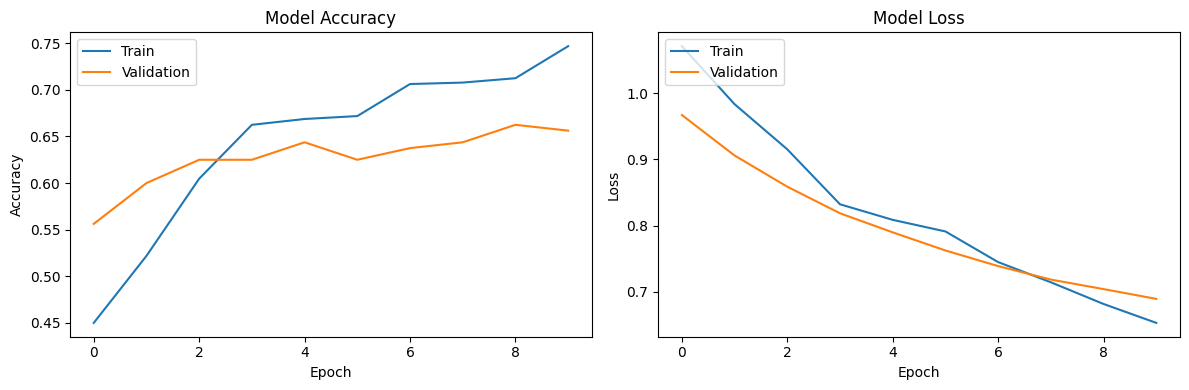

In [9]:
# 8. Visualize training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()



La siguiente imagen ilustra diferentes escenarios de sobreajuste al comparar la pérdida en entrenamiento (línea sólida) y validación (línea punteada) a lo largo de las iteraciones. Este gráfico fue extraído del libro Deep Learning with PyTorch de Eli Stevens, Luca Antiga y Thomas Viehmann (©2020, Manning Publications Co., todos los derechos reservados).

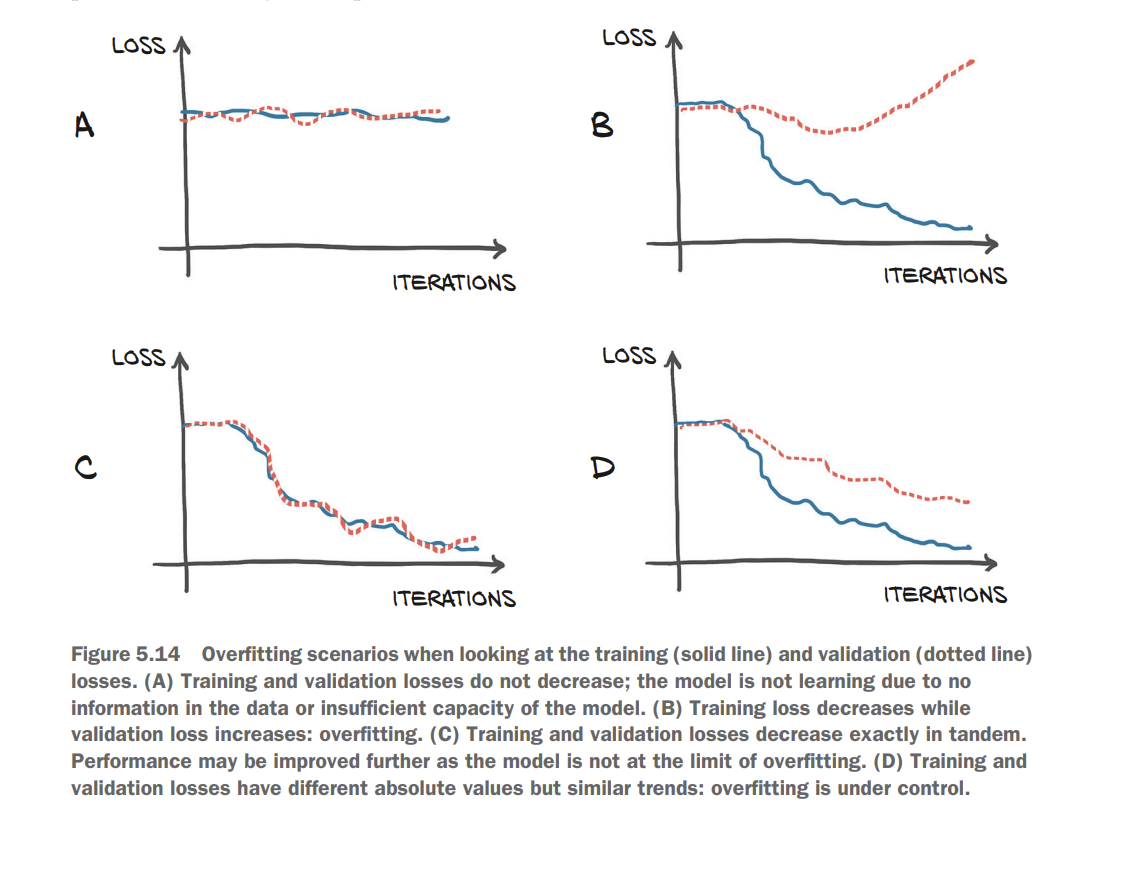


La matriz de confusión es una herramienta poderosa para evaluar el rendimiento de un modelo de clasificación. Nos muestra cuántas veces el modelo predijo correctamente cada clase y cómo se distribuyen los errores entre las diferentes clases.


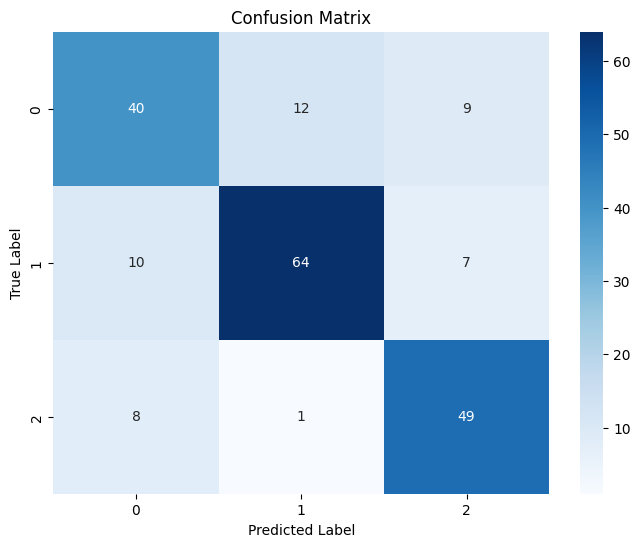

In [10]:
# 9. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()




Finalmente, vamos a guardar nuestro modelo entrenado para poder utilizarlo posteriormente sin necesidad de repetir todo el proceso de entrenamiento.

Este modelo representa la configuración óptima encontrada mediante nuestra búsqueda exhaustiva de hiperparámetros.


In [11]:
# 10. Save the best model
final_model.save('best_model.h5')
print("Model saved as 'best_model.h5'")


Model saved as 'best_model.h5'


## Consejos para Grid Search con Keras:

* Comienza con una grilla de parámetros pequeña y pocas épocas para probar tu configuración
* Utiliza early stopping para evitar perder tiempo en modelos poco prometedores
* Considera reducir el tamaño del conjunto de datos para experimentos iniciales
* Para grillas más grandes, considera usar la biblioteca [Keras Tuner](https://keras.io/keras_tuner/), que está optimizada para Keras. Esta es una alternativa a la implementación manual presentada en este colab.
* Utiliza aceleración GPU en Colab (Runtime > Change runtime type > GPU)
* Guarda resultados intermedios en caso de que el notebook se desconecte
* Utiliza el callback `ReduceLROnPlateau` para un entrenamiento más eficiente. `ReduceLROnPlateau` es un callback (función de retrollamada) de Keras que ajusta automáticamente la tasa de aprendizaje durante el entrenamiento del modelo. Su función principal es monitorear una métrica específica (generalmente la pérdida de validación) y reducir la tasa de aprendizaje cuando esta métrica deja de mejorar durante un número determinado de épocas.
* Considera añadir parámetros de regularización a la búsqueda de hiperparámetros

